In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df=pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

In [29]:
print(df.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations'],
      dtype='object')


In [30]:
print(df.head())

   Year  Month         Region    Model  Estimated_Deliveries  \
0  2023      5         Europe  Model S                 17646   
1  2015      2           Asia  Model X                  3797   
2  2019      1  North America  Model X                  8411   
3  2021      2  North America  Model 3                  6555   
4  2016     12    Middle East  Model Y                 12374   

   Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0             17922       92874.27                   120       704   
1              4164       62205.65                    75       438   
2              9189      117887.32                    82       480   
3              7311       89294.91                   120       712   
4             13537      114846.78                   120       661   

   CO2_Saved_tons           Source_Type  Charging_Stations  
0         1863.42  Interpolated (Month)              12207  
1          249.46    Official (Quarter)               7640  
2          

In [31]:
display(df.head())

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [32]:
df.info()
df.isnull().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


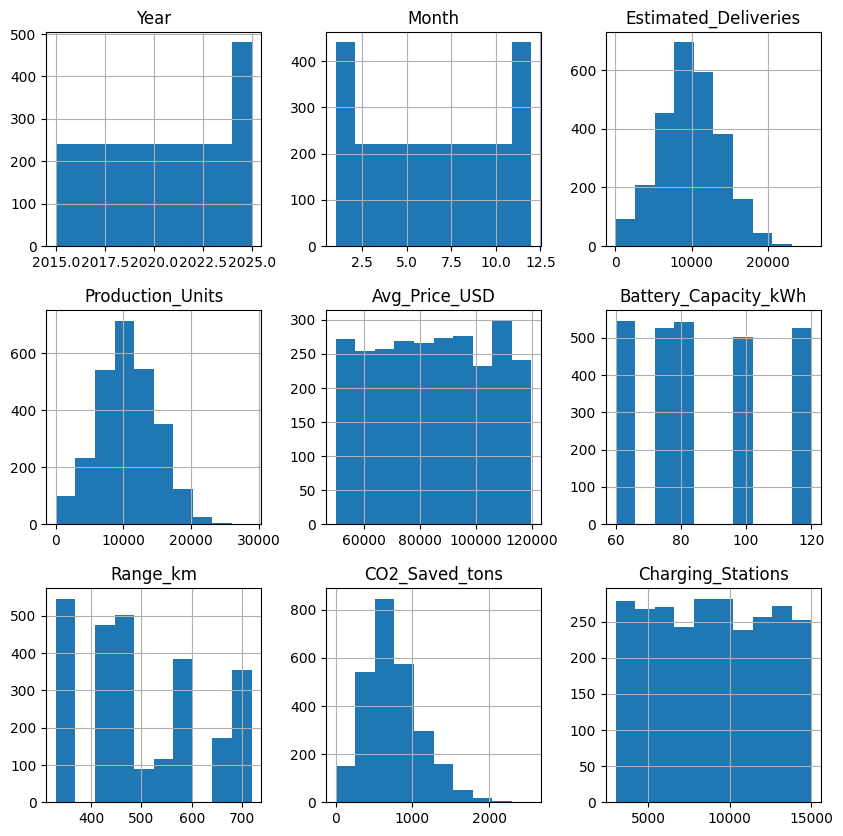

In [33]:
df.hist(figsize=(10 , 10))
plt.show()

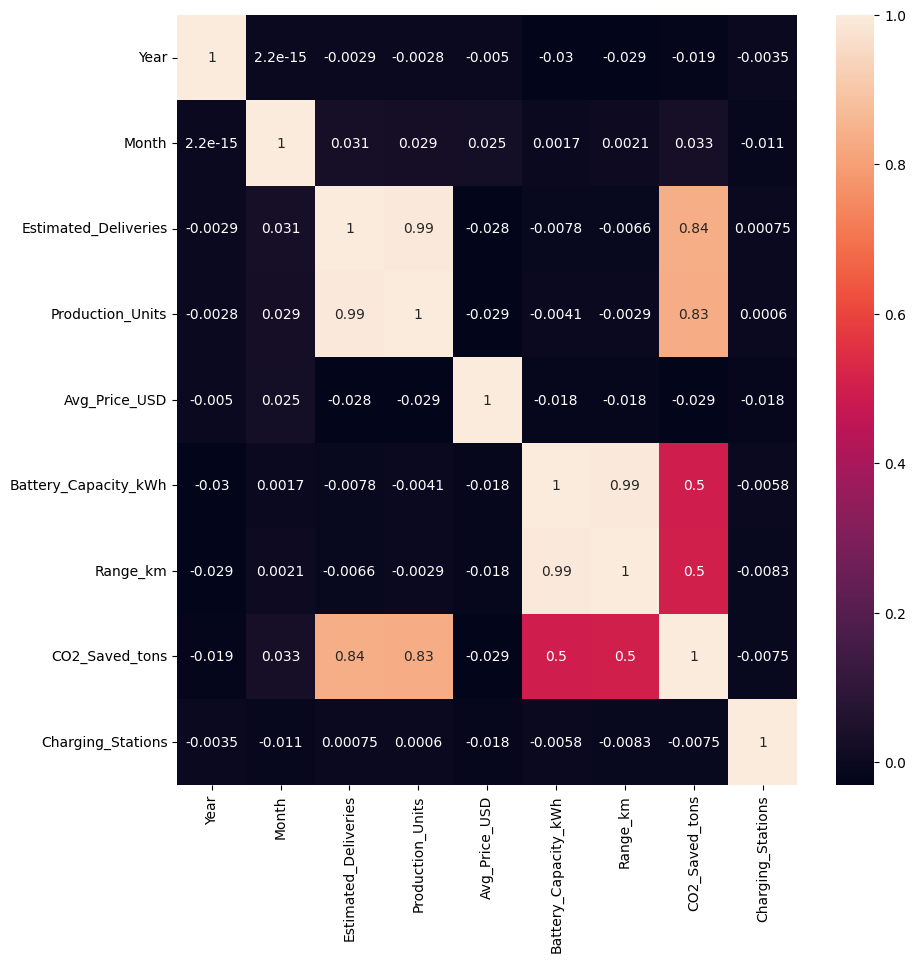

In [34]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

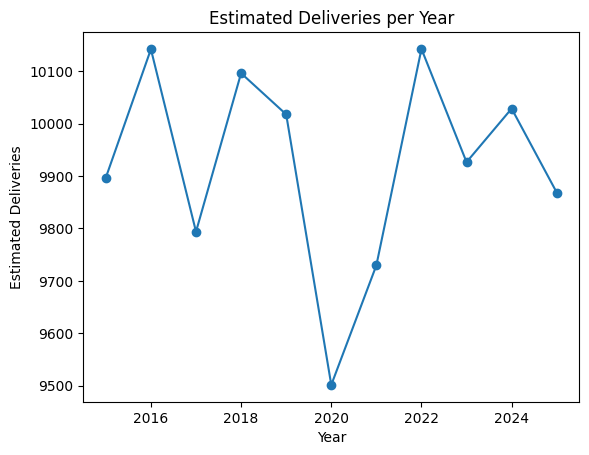

In [35]:
yearly = df.groupby('Year')['Estimated_Deliveries'].mean()
yearly.plot(marker='o')
plt.xlabel('Year')
plt.ylabel('Estimated Deliveries')
plt.title('Estimated Deliveries per Year')
plt.show()

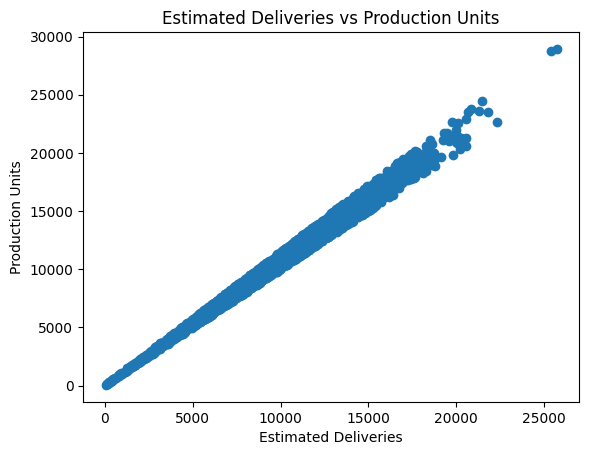

In [36]:
plt.scatter(
    df['Estimated_Deliveries'],
    df['Production_Units']
)
plt.xlabel('Estimated Deliveries')
plt.ylabel('Production Units')
plt.title('Estimated Deliveries vs Production Units')
plt.show()

In [37]:
df['Date']=pd.to_datetime(
    dict(
        year=df['Year'],
        month=df['Month'],
        day=1
    )
)
df[['Year','Month','Date']].head()

,Year,Month,Date
0,2023,5,2023-05-01
1,2015,2,2015-02-01
2,2019,1,2019-01-01
3,2021,2,2021-02-01
4,2016,12,2016-12-01


In [38]:
df['Quarter']=df['Date'].dt.quarter
df[['Date','Quarter']].head()

,Date,Quarter
0,2023-05-01,2
1,2015-02-01,1
2,2019-01-01,1
3,2021-02-01,1
4,2016-12-01,4


In [39]:
df['Year_From_Start']=df['Year']-df['Year'].min()
df[['Year','Year_From_Start']].head()

,Year,Year_From_Start
0,2023,8
1,2015,0
2,2019,4
3,2021,6
4,2016,1


In [40]:
df['Delivery_Efficiencies']= (
    df['Estimated_Deliveries']
    /df['Production_Units']
)

df['Delivery_Efficiencies'].describe()


,Delivery_Efficiencies
count,2640.000000
mean,0.932619
std,0.037232
min,0.869683
25%,0.899904
50%,0.932176
75%,0.964178
max,1.000000


In [41]:
df['CO2_per_Delivery']=(
    df['CO2_Saved_tons']
    /df['Estimated_Deliveries']
)
df['CO2_per_Delivery'].describe()

,CO2_per_Delivery
count,2640.000000
mean,0.075039
std,0.018130
min,0.049500
25%,0.062701
50%,0.070500
75%,0.087938
max,0.107850


In [42]:
df['price_per_KM']=(
    df['Avg_Price_USD']
    /df['Range_km']
)

In [43]:
print(df.columns)

Index(['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries',
       'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km',
       'CO2_Saved_tons', 'Source_Type', 'Charging_Stations', 'Date', 'Quarter',
       'Year_From_Start', 'Delivery_Efficiencies', 'CO2_per_Delivery',
       'price_per_KM'],
      dtype='object')


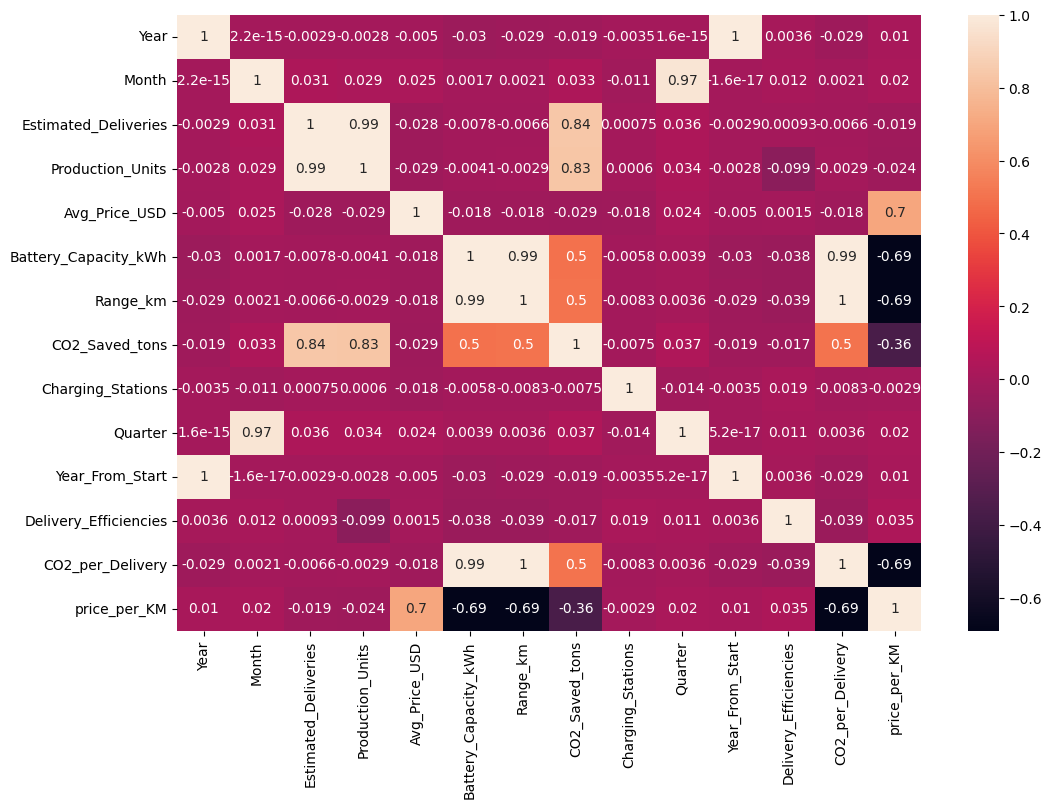

In [44]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [45]:
corr =df.corr(numeric_only=True)
print(
    corr['Estimated_Deliveries'].sort_values(ascending=False)
)

Estimated_Deliveries     1.000000
Production_Units         0.994234
CO2_Saved_tons           0.836814
Quarter                  0.035704
Month                    0.030877
Delivery_Efficiencies    0.000929
Charging_Stations        0.000753
Year_From_Start         -0.002863
Year                    -0.002863
Range_km                -0.006606
CO2_per_Delivery        -0.006607
Battery_Capacity_kWh    -0.007765
price_per_KM            -0.019372
Avg_Price_USD           -0.027546
Name: Estimated_Deliveries, dtype: float64


In [47]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score

In [48]:
x =df.drop(
    ['Estimated_Deliveries','Date'],
    axis=1
)
y=df['Estimated_Deliveries']

In [50]:
numerical_cols = x.select_dtypes(
    include=['int64','float64']
).columns
categorical_cols = x.select_dtypes(
    include=['object']
).columns

print ("Numerical Columns:",numerical_cols)

print ("Categorical Columns:",categorical_cols)


Numerical Columns: Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Year_From_Start', 'Delivery_Efficiencies',
       'CO2_per_Delivery', 'price_per_KM'],
      dtype='object')
Categorical Columns: Index(['Region', 'Model', 'Source_Type'], dtype='object')


In [51]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_cols),
        ('cat',OneHotEncoder(handle_unknown='ignore'),categorical_cols)
    ]
)


In [64]:
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [66]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Year_From_Start', 'Delivery_Efficiencies',
       'CO2_per_Delivery', 'price_per_KM'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Region', 'Model', 'Source_Type'], dtype='object'))])),
                ('model', LinearRegression())])

In [67]:
y_pred = pipeline.predict(X_test)

In [68]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 Score: 0.9984182667191381
MAE: 108.88732019126786
MSE: 23577.77203538506


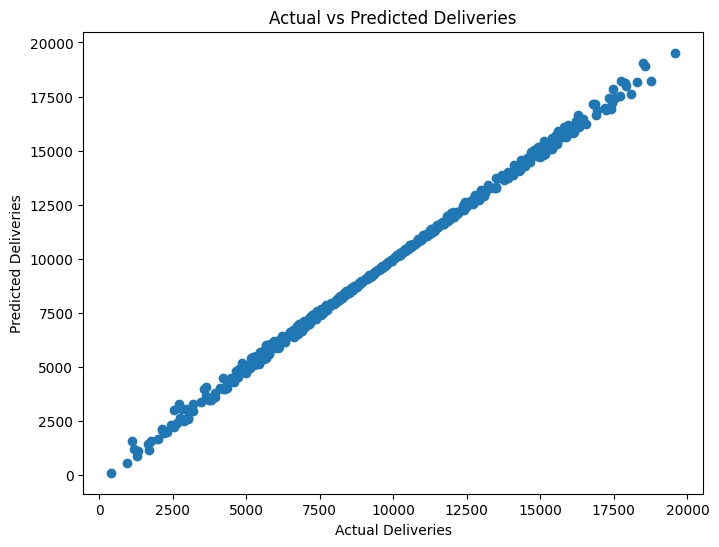

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")

plt.show()

Random Forest Model

In [70]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

rf_pipeline.fit(X_train, y_train)

rf_pred = rf_pipeline.predict(X_test)

In [71]:
print("R2 Score :", r2_score(y_test, rf_pred))
print("MSE :", mean_squared_error(y_test, rf_pred))

R2 Score : 0.9991728258191945
MSE : 12330.096675946963


In [72]:
from sklearn.model_selection import GridSearchCV

In [73]:
param_grid = {
    'model__n_estimators':[50,100,200],
    'model__max_depth':[5,10,None]
}

In [74]:
grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Year_From_Start', 'Delivery_Efficiencies',
       'CO2_per_Delivery', 'price_per_KM'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         Index(['Region', 'Model', 'Source_Type'], dtype='object'))])),
                                       ('model',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [5, 10, None],
                         'model__n_estimators': [50, 100, 200]},
             scoring='r2')

In [75]:
print("Best Parameters:")
print(grid_search.best_params_)

print("Best CV Score:")
print(grid_search.best_score_)

Best Parameters:
{'model__max_depth': None, 'model__n_estimators': 200}
Best CV Score:
0.9981802199685994


In [76]:
best_model = grid_search.best_estimator_

best_pred = best_model.predict(X_test)

print("Final R2 :", r2_score(y_test, best_pred))
print("Final MSE :", mean_squared_error(y_test, best_pred))

Final R2 : 0.9991560028145887
Final MSE : 12580.865229876903


# Time Series Forecastin


In [77]:
#monthly
monthly_data = df.groupby(
    ['Year', 'Month']
)['Estimated_Deliveries'].sum().reset_index()

In [78]:
monthly_data['Date'] = pd.to_datetime(
    dict(
        year=monthly_data['Year'],
        month=monthly_data['Month'],
        day=1
    )
)

In [79]:
monthly_data = monthly_data.set_index('Date')

In [80]:
monthly_data.head()

,Year,Month,Estimated_Deliveries
Date,,,
2015-01-01,2015,1,183180
2015-02-01,2015,2,165053
2015-03-01,2015,3,184567
2015-04-01,2015,4,225623
2015-05-01,2015,5,184264


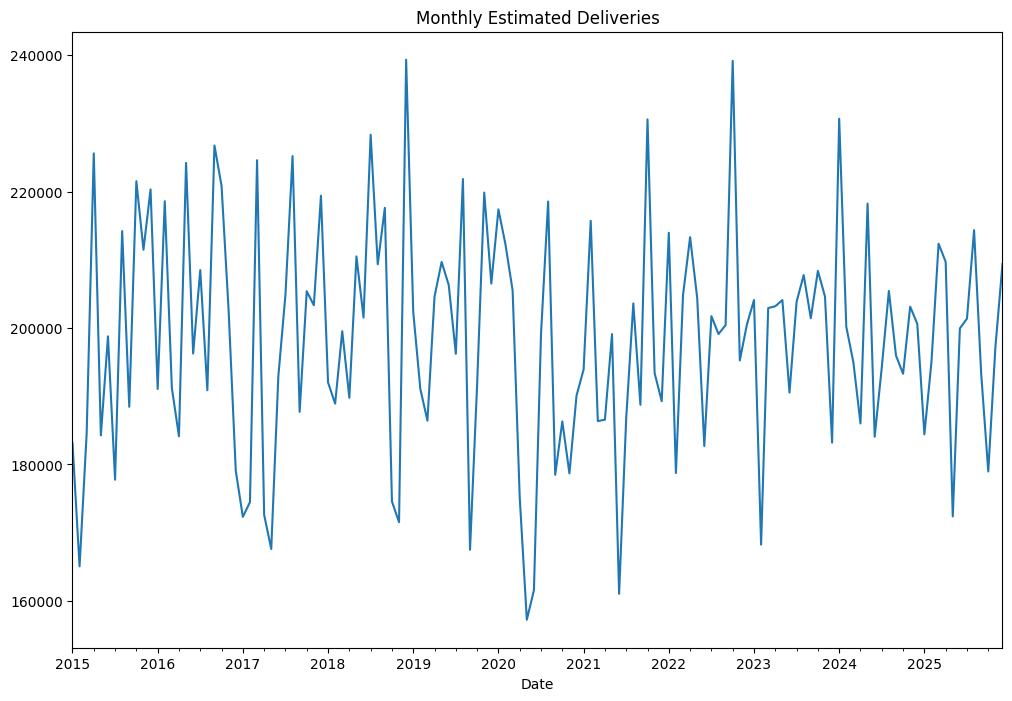

In [82]:
monthly_data['Estimated_Deliveries'].plot(
    figsize=(12,8)
)

plt.title("Monthly Estimated Deliveries")
plt.show()

In [83]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(
    monthly_data['Estimated_Deliveries'],
    order=(5,1,0)
)

arima_result = arima_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [84]:
forecast = arima_result.forecast(steps=12)

print(forecast)

2026-01-01    203819.655291
2026-02-01    202894.176208
2026-03-01    199011.662577
2026-04-01    198667.010489
2026-05-01    200971.493839
2026-06-01    201391.449843
2026-07-01    201412.663910
2026-08-01    201031.409119
2026-09-01    200601.086701
2026-10-01    200710.068214
2026-11-01    200864.721560
2026-12-01    200936.680134
Freq: MS, Name: predicted_mean, dtype: float64


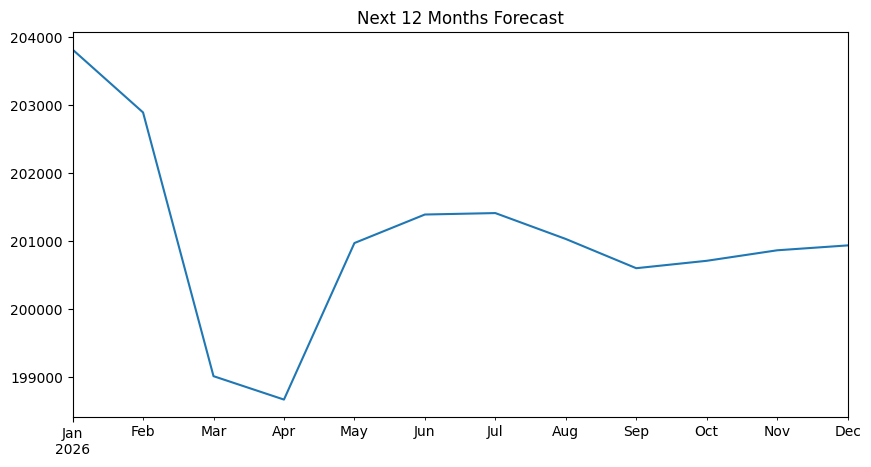

In [85]:
forecast.plot(figsize=(10,5))

plt.title("Next 12 Months Forecast")
plt.show()